In [162]:
import os
# Вимкнення зайвих логів TensorFlow тут щоб потім не вказувати це в кожному місці
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer, make_column_selector

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping

In [163]:
BASE_DIR = Path.cwd()
file_name = 'pokedex_b.csv'
DATA_PATH = BASE_DIR / 'data' / file_name
RANDOM_SEED = 42
TEST_SIZE = 0.2

try:
    df = pd.read_csv(DATA_PATH)
    print("File loaded successfully.")
except FileNotFoundError:
    print("File not found. Please check the file path and name.")


File loaded successfully.


In [164]:
from IPython.display import display, Markdown
display(Markdown(f"### Shape: {df.shape[0]} rows, {df.shape[1]} columns"))
display(df.head())

display(Markdown("### Info"))
df.info()

### Shape: 1402 rows, 14 columns

,pokedex_number,name,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,type,weight_kg,generation,is_legendary
0,144,Articuno,85,100,1.7,90,0.0,95,125,85,ice,55.4,1,1
1,145,Zapdos,90,85,1.6,90,0.0,125,90,100,electric,52.6,1,1
2,146,Moltres,100,90,2.0,90,0.0,125,85,90,fire,60.0,1,1
3,150,Mewtwo,150,70,2.0,106,0.0,194,120,140,psychic,122.0,1,1
4,151,Mew,100,100,0.4,100,0.0,100,100,100,psychic,4.0,1,1


### Info

<class 'pandas.DataFrame'>
RangeIndex: 1402 entries, 0 to 1401
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pokedex_number   1402 non-null   int64  
 1   name             1402 non-null   str    
 2   attack           1402 non-null   int64  
 3   defense          1402 non-null   int64  
 4   height_m         1402 non-null   float64
 5   hp               1402 non-null   int64  
 6   percentage_male  1402 non-null   float64
 7   sp_attack        1402 non-null   int64  
 8   sp_defense       1402 non-null   int64  
 9   speed            1402 non-null   int64  
 10  type             1402 non-null   str    
 11  weight_kg        1402 non-null   float64
 12  generation       1402 non-null   int64  
 13  is_legendary     1402 non-null   int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 153.5 KB


Перевіряємо, наскільки збалансована кількість зразків кожного класу. В нашому випадку доля класу приблизно однаковою.

In [165]:
df['is_legendary'].value_counts(normalize=True)

is_legendary
0    0.507846
1    0.492154
Name: proportion, dtype: float64

In [166]:
df_cleaned = df.drop(columns=['name', 'pokedex_number'])
df_cleaned.head()

,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,type,weight_kg,generation,is_legendary
0,85,100,1.7,90,0.0,95,125,85,ice,55.4,1,1
1,90,85,1.6,90,0.0,125,90,100,electric,52.6,1,1
2,100,90,2.0,90,0.0,125,85,90,fire,60.0,1,1
3,150,70,2.0,106,0.0,194,120,140,psychic,122.0,1,1
4,100,100,0.4,100,0.0,100,100,100,psychic,4.0,1,1


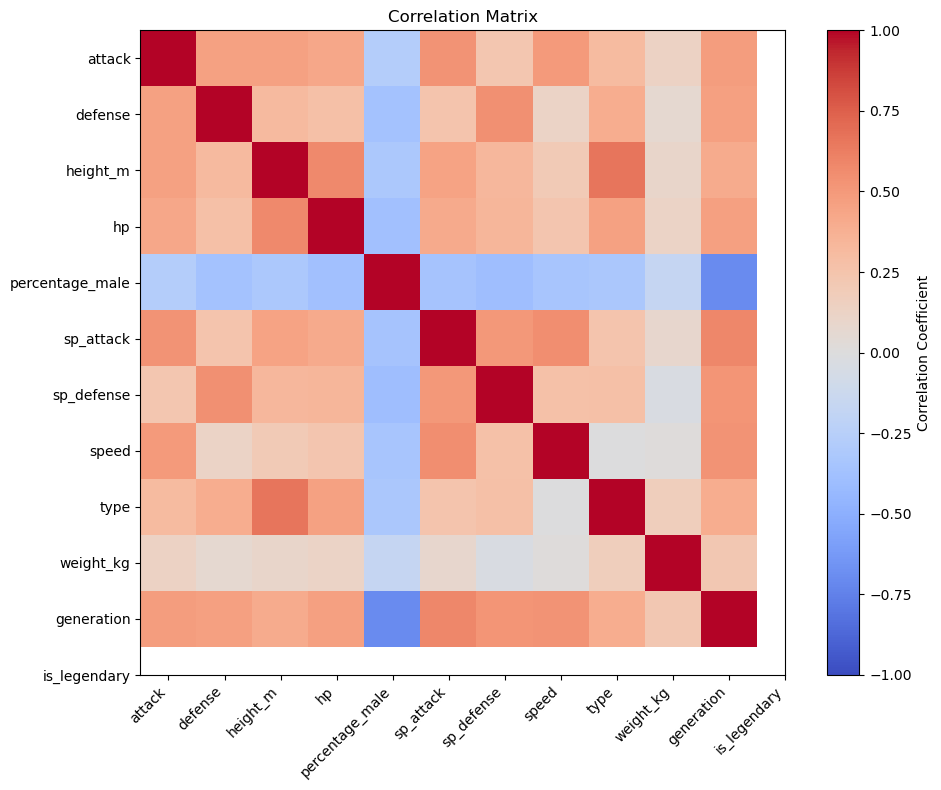

In [167]:
plt.figure(figsize=(10, 8))
plt.imshow(df_cleaned.corr(numeric_only=True), cmap='coolwarm', interpolation='nearest', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.title('Correlation Matrix')

# Додаємо назви колонок на осі
columns = df_cleaned.columns
plt.xticks(range(len(columns)), columns, rotation=45, ha='right')
plt.yticks(range(len(columns)), columns)

plt.tight_layout()
plt.show()

In [168]:
df_cleaned = df_cleaned.join(pd.get_dummies(df_cleaned['type'], drop_first=True, prefix='type'))
df_cleaned.drop(columns=['type'], inplace=True)
df_cleaned.head()

,attack,defense,height_m,hp,percentage_male,sp_attack,sp_defense,speed,weight_kg,generation,...,type_ghost,type_grass,type_ground,type_ice,type_normal,type_poison,type_psychic,type_rock,type_steel,type_water
0,85,100,1.7,90,0.0,95,125,85,55.4,1,...,False,False,False,True,False,False,False,False,False,False
1,90,85,1.6,90,0.0,125,90,100,52.6,1,...,False,False,False,False,False,False,False,False,False,False
2,100,90,2.0,90,0.0,125,85,90,60.0,1,...,False,False,False,False,False,False,False,False,False,False
3,150,70,2.0,106,0.0,194,120,140,122.0,1,...,False,False,False,False,False,False,True,False,False,False
4,100,100,0.4,100,0.0,100,100,100,4.0,1,...,False,False,False,False,False,False,True,False,False,False


In [169]:
X = df_cleaned.drop(columns=['is_legendary']).values
y = df_cleaned['is_legendary'].values
y = to_categorical(y, num_classes=2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y)
print(X_train.shape, y_train.shape)

(1121, 27) (1121, 2)


In [170]:
is_binary = np.all(np.isin(X_train, [0, 1]), axis=0)

cols_to_scale = ~is_binary

scaler = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), cols_to_scale),
    ],
    remainder='passthrough'
)

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [171]:
model = Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu', kernel_regularizer= keras.regularizers.L2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(8, activation='relu', kernel_regularizer= keras.regularizers.L2(0.001)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(2, activation='sigmoid', kernel_regularizer= keras.regularizers.L2(0.001)) 
])

In [172]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 32)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,338 (5.23 KB)

 Trainable params: 1,258 (4.91 KB)

 Non-trainable params: 80 (320.00 B)

In [173]:
early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=64,          
    batch_size=16,      
    validation_split=0.1, 
    verbose=1,
    callbacks=[early]
)

Epoch 1/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6419 - loss: 0.7066 - val_accuracy: 0.8584 - val_loss: 0.5915
Epoch 2/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8294 - loss: 0.4827 - val_accuracy: 0.9204 - val_loss: 0.4542
Epoch 3/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8760 - loss: 0.3959 - val_accuracy: 0.9204 - val_loss: 0.3486
Epoch 4/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8929 - loss: 0.3547 - val_accuracy: 0.9469 - val_loss: 0.2778
Epoch 5/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9087 - loss: 0.3003 - val_accuracy: 0.9381 - val_loss: 0.2374
Epoch 6/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9296 - loss: 0.2666 - val_accuracy: 0.9469 - val_loss: 0.2040
Epoch 7/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9256 - loss: 0.2551 - val_accuracy: 0.9469 - val_loss: 0.1838
Epoch 8/64
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9246 - loss: 0.2502 - val_accuracy: 0.9558 - val_loss

In [174]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(loss, accuracy)

0.08644519746303558 0.9893238544464111


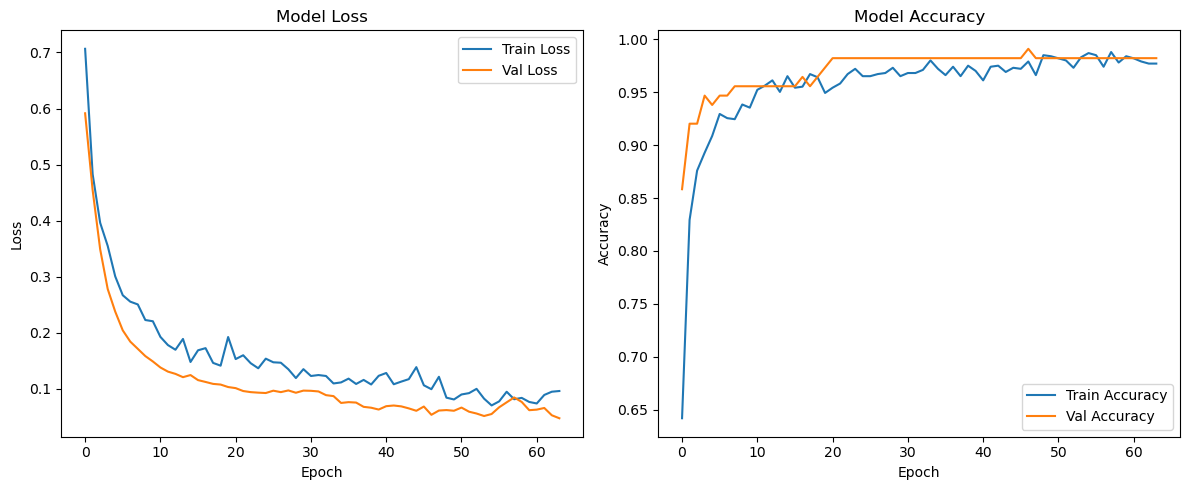

In [175]:
plt.figure(figsize=(12, 5))

# Графік втрат (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Графік точності (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [176]:
import random

random_idx = random.randint(0, X_test.shape[0] - 1)
sample = X_test[random_idx].reshape(1, -1) 

prediction_probs = model.predict(sample, verbose=0)
predicted_class = np.argmax(prediction_probs) 
confidence = np.max(prediction_probs) * 100  

true_class = np.argmax(y_test[random_idx]) 

print(f"\n--- Результат передбачення для зразка #{random_idx} ---")
print(f"Істинний клас: {true_class}")
print(f"Передбачено клас {predicted_class} з достовірністю {confidence:.2f}%")


--- Результат передбачення для зразка #88 ---
Істинний клас: 1
Передбачено клас 1 з достовірністю 99.92%


In [177]:
model.save('islegendary.keras')